# Hospital Readmission Risk Prediction

Dataset from Kaggle: https://www.kaggle.com/datasets/miadul/hospital-readmission-risk-dataset/data 

The goal of this project is to predict the risk of re-hospitalization of a patient

Classification problem with 3 classes

# Basic Imports

In [353]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [354]:
df = pd.read_csv("hospital_readmission_risk_10000.csv")
print(f"Shape of the dataset: {df.shape}")
display(df.head())

Shape of the dataset: (9999, 23)


,patient_id,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
0,d8fd1a56-a5d8-499b-917c-f9ac8d369f9b,18,Male,57,157,23.1,8,Heart Disease,8,16.2,...,7,0,Current,Moderate,Medium,Private,Poor,Weak,Yes,Medium
1,2e9b4349-69e5-494f-b806-947ec5b5bb7c,23,Female,117,150,52.0,6,Diabetes,6,13.1,...,21,2,Never,High,Medium,Private,Good,Weak,Yes,High
2,6f279c22-3b20-4328-9dac-466de7c47a51,80,Female,61,141,30.7,5,Heart Disease,8,15.4,...,2,0,Never,Moderate,Low,Public,Good,Weak,No,Low
3,1af43d48-79a9-4408-a1f1-13c58d7221fd,15,Female,47,164,17.5,0,Hypertension,1,14.2,...,8,3,Former,NaN,High,Private,Good,Weak,No,High
4,e7903dbe-839e-4ea6-a6d0-83438a981a9b,14,Male,67,179,20.9,6,Heart Disease,0,14.7,...,3,0,Former,High,High,Uninsured,Poor,Weak,No,Medium


In [355]:
print("Types of data:")
print(df.dtypes)


Types of data:
patient_id                     str
age                          int64
gender                         str
weight_kg                    int64
height_cm                    int64
bmi                        float64
num_previous_admissions      int64
chronic_conditions             str
medications_count            int64
last_hemoglobin            float64
last_glucose               float64
last_creatinine            float64
admission_type                 str
length_of_stay               int64
procedures_count             int64
smoking_status                 str
alcohol_use                    str
physical_activity              str
insurance_type                 str
followup_compliance            str
social_support                 str
mental_health_issue            str
readmission_risk               str
dtype: object


**Analyzing the target variable**

Text(0, 0.5, 'Count')

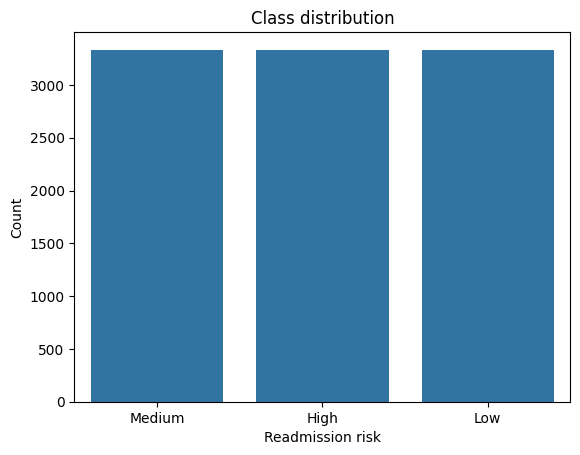

In [356]:
plt.figure()
sns.countplot(x=df['readmission_risk'])
plt.title("Class distribution")
plt.xlabel('Readmission risk')
plt.ylabel('Count')

**Check missing or invalid values**

In [357]:
missing_values = df.isnull().sum()
print("Missing values analysis: ")
print(missing_values[missing_values > 0])

Missing values analysis: 
chronic_conditions    2032
alcohol_use           3243
dtype: int64


In [358]:
print(df['chronic_conditions'].unique())
print(df['alcohol_use'].unique())

<StringArray>
['Heart Disease', 'Diabetes', 'Hypertension', nan, 'COPD']
Length: 5, dtype: str
<StringArray>
['Moderate', 'High', nan]
Length: 3, dtype: str


This dataset actually has a category 'None' in columns 'alcohol_use' and 'chronic_conditions' that indicates that the patient doesn't drink alcohol or doesn't have any chronic conditions.

We will solve this in the **Preprocessing** section

In [359]:
df.describe()

,age,weight_kg,height_cm,bmi,num_previous_admissions,medications_count,last_hemoglobin,last_glucose,last_creatinine,length_of_stay,procedures_count
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.00000,9999.000000,9999.000000
mean,44.464046,79.254825,169.377138,28.546015,4.497050,4.433643,13.994369,135.485759,1.24427,15.051805,2.010301
std,25.987773,23.168501,17.347572,10.450597,2.869846,2.874026,2.297621,37.488959,0.43686,8.360688,1.414848
min,0.000000,40.000000,140.000000,10.100000,0.000000,0.000000,10.000000,70.000000,0.50000,1.000000,0.000000
25%,22.000000,59.000000,154.000000,20.400000,2.000000,2.000000,12.000000,102.800000,0.86000,8.000000,1.000000
50%,45.000000,79.000000,169.000000,27.400000,5.000000,4.000000,14.000000,135.500000,1.24000,15.000000,2.000000
75%,67.000000,99.000000,184.500000,35.100000,7.000000,7.000000,16.000000,168.400000,1.62000,22.000000,3.000000
max,89.000000,119.000000,199.000000,60.200000,9.000000,9.000000,18.000000,200.000000,2.00000,29.000000,4.000000


Min and max 'bmi' values are extreme, but also medically possible, so we will not exclude them.

Min 'age' is 0, which indicates the presence of newborns, we will also consider that a valid value.

Conclusion: no invalid values present in dataset

In [360]:
numerical_cols = df.select_dtypes(include=np.number).columns.to_list()
print(f"Number od numerical columns: {len(numerical_cols)}") 
print(numerical_cols)

Number od numerical columns: 11
['age', 'weight_kg', 'height_cm', 'bmi', 'num_previous_admissions', 'medications_count', 'last_hemoglobin', 'last_glucose', 'last_creatinine', 'length_of_stay', 'procedures_count']


<Axes: >

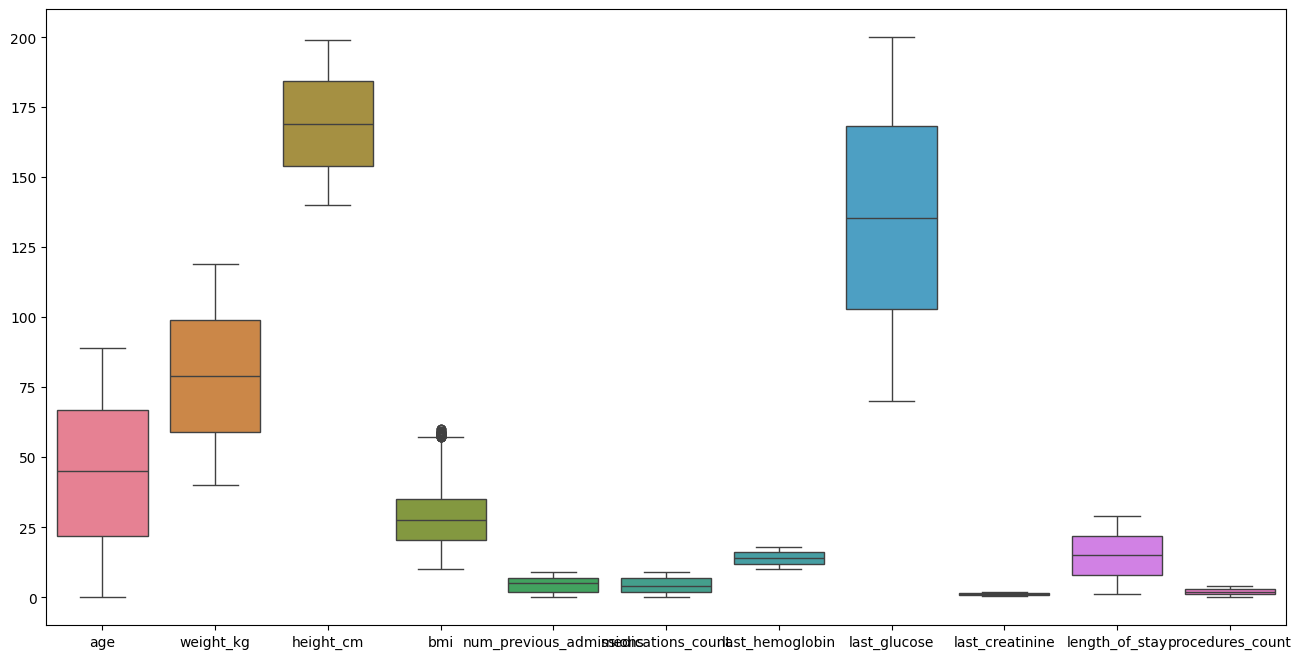

In [361]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df[numerical_cols])

<Axes: xlabel='bmi'>

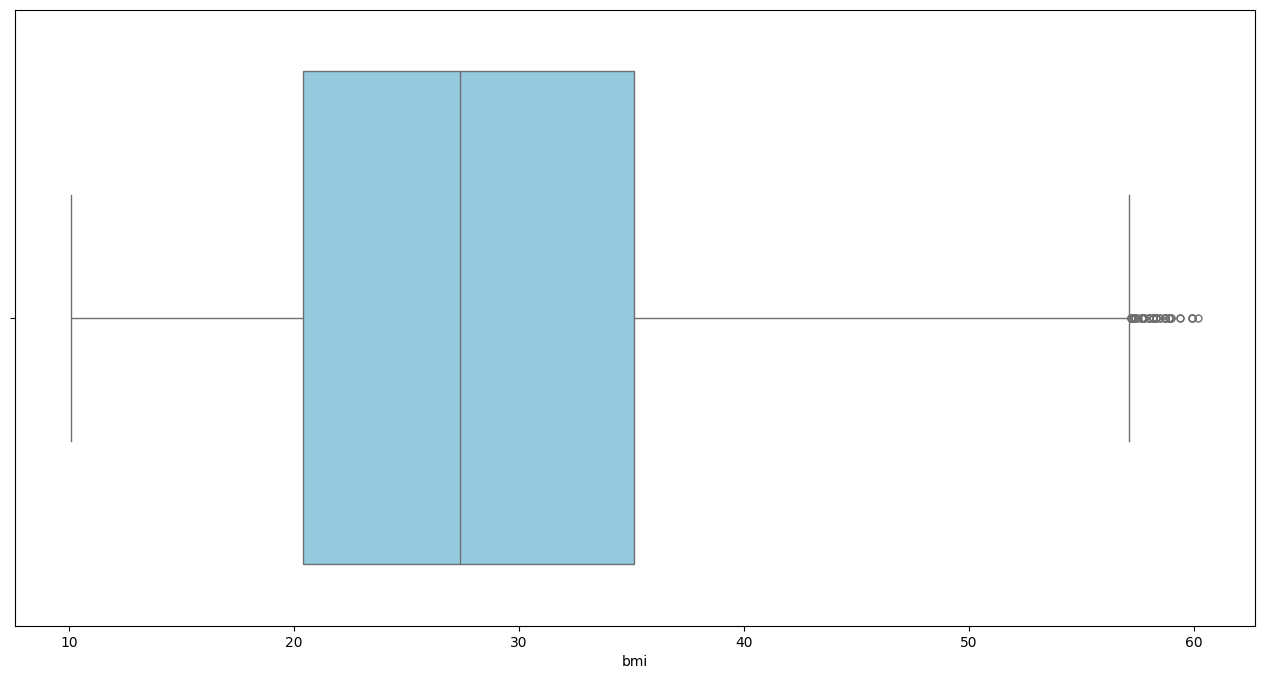

In [362]:
plt.figure(figsize=(16, 8))
sns.boxplot(x=df['bmi'], color='skyblue', fliersize=5)

In [363]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
display(outliers.head())


Lower bound: -1.6500000000000057
Upper bound: 57.150000000000006
Number of outliers: 52


,patient_id,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
19,8f1c9eee-fd89-47ef-a932-3d47cfe2afc7,72,Female,119,144,57.4,4,COPD,0,16.0,...,8,4,Former,Moderate,High,Public,Poor,Weak,Yes,Medium
688,afb828b9-db28-4bbc-9cc5-29fc5deb7271,13,Female,119,144,57.4,1,NaN,9,11.9,...,11,4,Current,High,High,Private,Good,Weak,Yes,High
1042,5389fb7d-f809-4318-9290-dfb717bd3673,72,Male,115,140,58.7,5,Diabetes,2,15.6,...,1,2,Current,High,Medium,Uninsured,Good,Weak,No,High
1136,b1bd61c5-bddf-4c08-b848-d57be482190b,82,Female,115,141,57.8,1,Diabetes,0,12.9,...,15,1,Former,High,Medium,Public,Good,Strong,Yes,Medium
1427,95fdd21f-25f9-457e-a352-90f5b4b351e9,21,Female,115,141,57.8,4,Hypertension,9,10.8,...,17,2,Current,Moderate,Medium,Uninsured,Poor,Weak,No,High


<Axes: xlabel='readmission_risk', ylabel='count'>

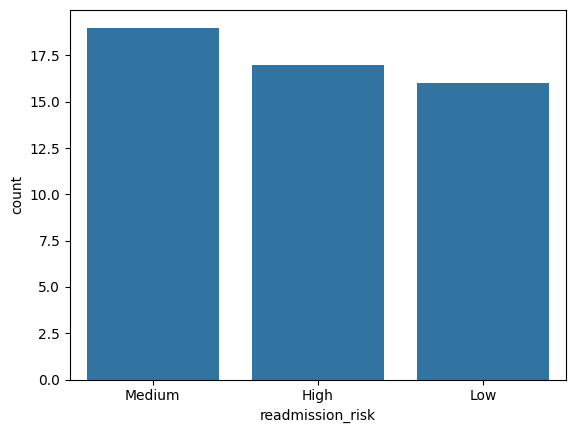

In [364]:
sns.countplot(data=outliers, x='readmission_risk')

Analysis of extreme values ​​(outliers) in the BMI column showed that patients with an extremely high bmi do not necessarily belong to the high-risk group. The distribution of classes within outliers follows the general distribution of the entire data set. This suggests that BMI, although important, is not an isolated factor independently dictating the risk of rehospitalization in this dataset.

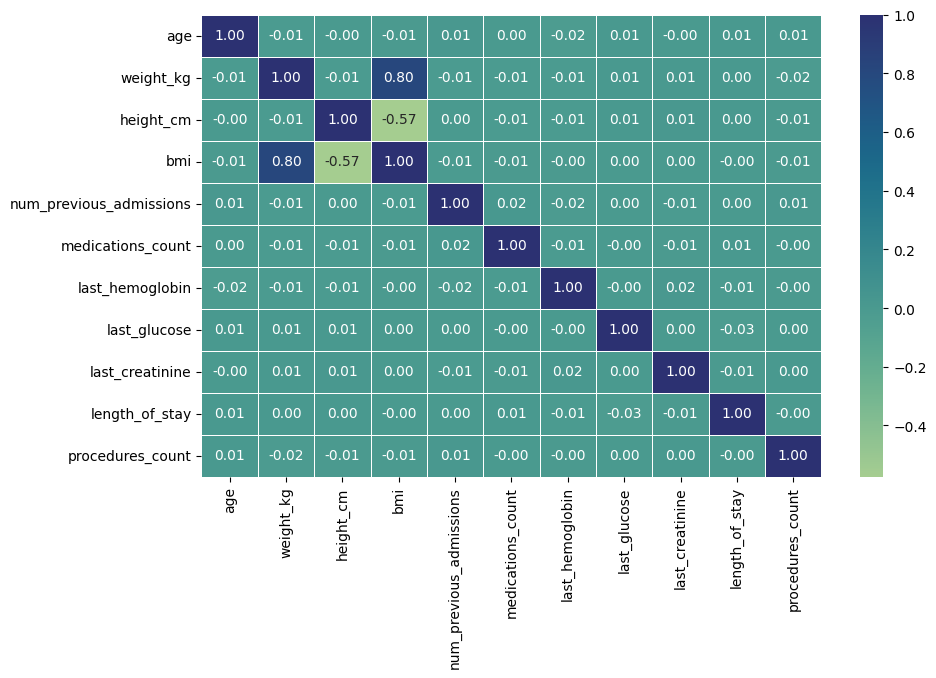

In [365]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="crest",   
    fmt=".2f",
    linewidths=.5
)
plt.show()

BMI is derived from weight and height, so we will only keep bmi to avoid redundancy.

# Preprocessing

Pandas recognized the 'None' category  as NaN, so we will fill those 'missing' values with the string 'None'.

In [366]:
df['chronic_conditions'] = df['chronic_conditions'].fillna('None')
df['alcohol_use'] = df['alcohol_use'].fillna('None')

print(df['chronic_conditions'].value_counts())
print()
print(df['alcohol_use'].value_counts())

chronic_conditions
Diabetes         2034
None             2032
Hypertension     2021
COPD             1994
Heart Disease    1918
Name: count, dtype: int64

alcohol_use
High        3398
Moderate    3358
None        3243
Name: count, dtype: int64


This way, we brought back 'None' as a valid category

Correlation matrix in **EDA** gave us an indication that height and weight are not needed, so we will remove those columns.

As well as, column 'patient_id' is irrelevant in this prediction.

In [367]:
df.drop(['patient_id','weight_kg', 'height_cm'], axis = 1, inplace = True)